# Import Data and Segment into train, temp, test

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np



PATHIM = "data//mnist_large//images.csv"
PATHLB = "data//mnist_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

""" Create a test and train set """
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.30, random_state=42, stratify=labels)


# Check Data

In [9]:
print(f"Shape images: {images.shape}")
print(f"Shape labels: {labels.shape}")

print(f"Shape train: {x_train.shape}")
print(f"Shape train target: {y_train.shape}")

print(f"Shape test: {x_test.shape}")
print(f"Shape test target: {y_test.shape}")


# To check the class labels:
print(f"{y_train["label"].value_counts()}")
print(f"{y_test["label"].value_counts()}")


Shape images: (10000, 784)
Shape labels: (10000, 1)
Shape train: (7000, 784)
Shape train target: (7000, 1)
Shape test: (3000, 784)
Shape test target: (3000, 1)
label
8    700
2    700
0    700
5    700
9    700
6    700
4    700
1    700
7    700
3    700
Name: count, dtype: int64
label
1    300
2    300
3    300
4    300
0    300
5    300
9    300
7    300
6    300
8    300
Name: count, dtype: int64


# Perform Dimensional Reduction

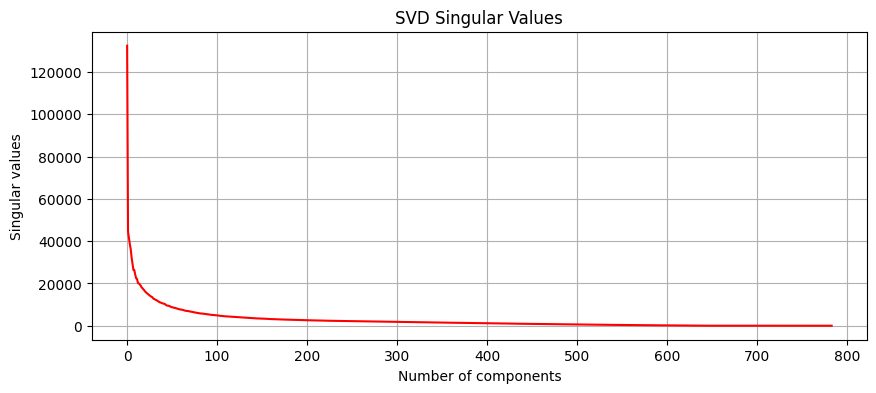

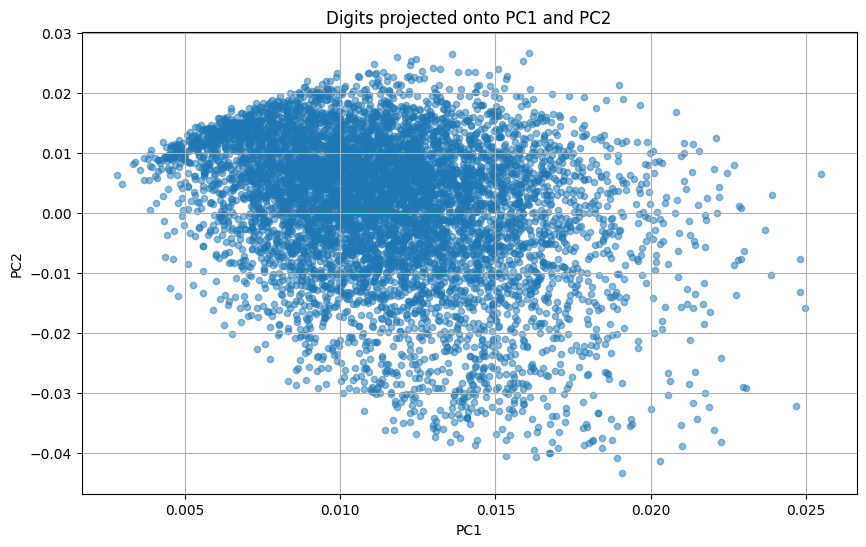

In [10]:
# Compute SVD
U, S, Vt = np.linalg.svd(x_train, full_matrices=False)

# Plot eigenvalues (singular values)
plt.figure(figsize=(10, 4))
plt.plot(S, 'r-')
plt.xlabel('Number of components')
plt.ylabel('Singular values')
plt.title('SVD Singular Values')
plt.grid(True)
plt.show()

# Plot PC1 vs PC2
plt.figure(figsize=(10, 6))
plt.scatter(U[:, 0], U[:, 1], alpha=0.5, s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Digits projected onto PC1 and PC2')
plt.grid(True)
plt.show()

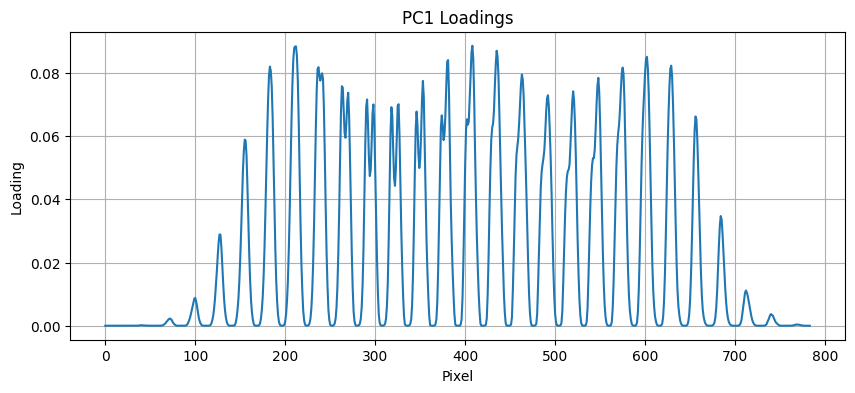

In [5]:
# Plot the loading vector for PC1
plt.figure(figsize=(10, 4))
plt.plot(Vt[0, :])
plt.xlabel('Pixel')
plt.ylabel('Loading')
plt.title('PC1 Loadings')
plt.grid(True)
plt.show()

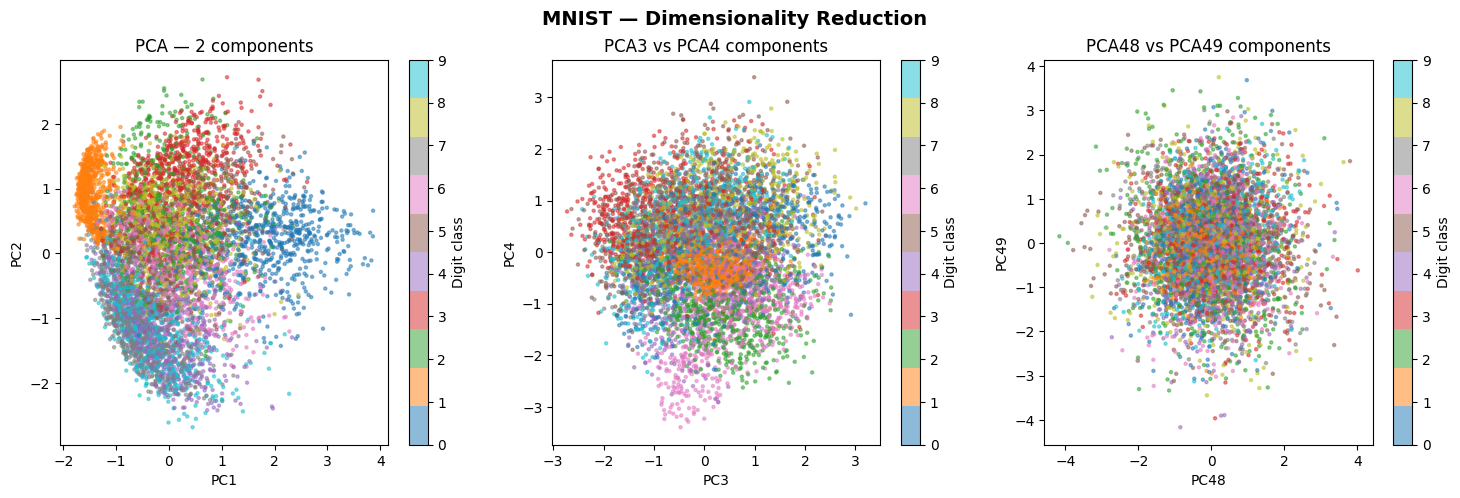

In [16]:
from sklearn.decomposition import PCA


#PCA with 50 Conponents, Whiten = rescale around zero with unit variance
pca50 = PCA(n_components=50, svd_solver='full', whiten=True)
pca50_train = pca50.fit_transform(x_train)
pca50_test = pca50.transform(x_test)



fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MNIST — Dimensionality Reduction", fontsize=14, fontweight="bold")

# PCA1 v PCA2 scatter
sc1 = axes[0].scatter(pca50_train[:, 0], pca50_train[:, 1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[0].set_title("PCA — 2 components")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Digit class")

# PCA3 v PCA4 scatter
sc1 = axes[1].scatter(pca50_train[:, 2], pca50_train[:, 3],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[1].set_title("PCA3 vs PCA4 components")
axes[1].set_xlabel("PC3"); axes[1].set_ylabel("PC4")
plt.colorbar(sc1, ax=axes[1], label="Digit class")

# PCA5 v PCA6 scatter
sc1 = axes[2].scatter(pca50_train[:, -2], pca50_train[:, -1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[2].set_title("PCA48 vs PCA49 components")
axes[2].set_xlabel("PC48"); axes[2].set_ylabel("PC49")
plt.colorbar(sc1, ax=axes[2], label="Digit class")

# KNN - Cross Validation

In [20]:
from sklearn.model_selection import StratifiedKFold

five_fold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2547)

for train_idx, val_idx in five_fold_cv.split(pca50_train, y_train.values):
    pca50_train_fold = pca50_train[train_idx]
    y_train_fold = y_train.values[train_idx]
    pca50_val_fold = pca50_train[val_idx]
    y_val_fold = y_train.values[val_idx]



In [21]:
# Make sure train and val indices don't overlap
assert len(set(train_idx) & set(val_idx)) == 0

In [22]:
from sklearn.neighbors import KNeighborsClassifier

# Apply to train

k_vals = [2*x+1 for x in range(20)]
k_error_rate = {}

for n in k_vals:
    k_error_rate[f"{n}"] = []

k_var = {}

for n in k_vals:
    print(n)

    for train_idx, val_idx in five_fold_cv.split(pca50_train, np.ravel(y_train)):
        pca50_train_fold = pca50_train[train_idx]
        y_train_fold = np.ravel(y_train)[train_idx]
        pca50_val_fold = pca50_train[val_idx]
        y_val_fold = np.ravel(y_train)[val_idx]

        #fit model
        neigh = KNeighborsClassifier(n_neighbors=n, metric= "euclidean")
        neigh.fit(pca50_train_fold, y_train_fold)

        # Predict and calculate errors
        k_error_rate[f"{n}"].append(np.mean(neigh.predict(pca50_val_fold) != y_val_fold))



for n in k_vals:
    print(f"{n}: {k_error_rate[f"{n}"]}")



1
3
5
7
9
11
13
15
17
19
21
23
25
27
29
31
33
35
37
39
1: [np.float64(0.07), np.float64(0.06928571428571428), np.float64(0.07285714285714286), np.float64(0.07428571428571429), np.float64(0.08285714285714285)]
3: [np.float64(0.07642857142857143), np.float64(0.07142857142857142), np.float64(0.07214285714285715), np.float64(0.07428571428571429), np.float64(0.07428571428571429)]
5: [np.float64(0.07571428571428572), np.float64(0.07857142857142857), np.float64(0.06857142857142857), np.float64(0.06928571428571428), np.float64(0.08)]
7: [np.float64(0.08), np.float64(0.08642857142857142), np.float64(0.07428571428571429), np.float64(0.07928571428571428), np.float64(0.08642857142857142)]
9: [np.float64(0.08142857142857143), np.float64(0.08214285714285714), np.float64(0.08214285714285714), np.float64(0.085), np.float64(0.09)]
11: [np.float64(0.08214285714285714), np.float64(0.08357142857142857), np.float64(0.07571428571428572), np.float64(0.085), np.float64(0.09285714285714286)]
13: [np.float64(0.

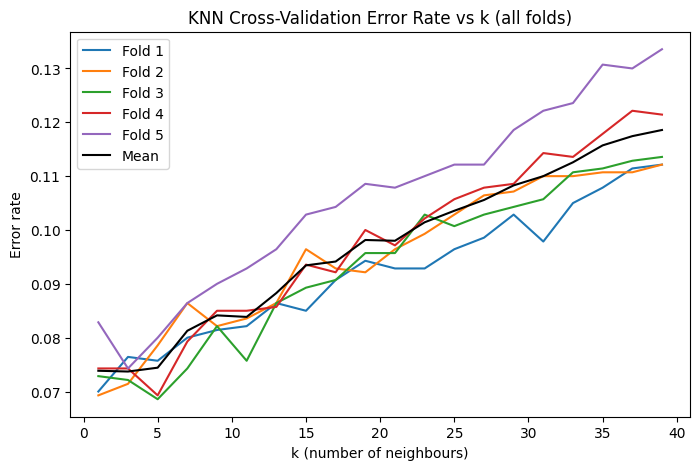

In [23]:
plt.figure(figsize=(8, 5))

# Plot each fold as a separate line
n_folds = len(k_error_rate[f"{k_vals[0]}"])
for fold in range(n_folds):
    fold_errors = [k_error_rate[f"{n}"][fold] for n in k_vals]
    plt.plot(k_vals, fold_errors,  label=f'Fold {fold+1}')

# Plot mean on top
k_means = [np.mean(k_error_rate[f"{n}"]) for n in k_vals]
plt.plot(k_vals, k_means, color='black', label='Mean', zorder=5)

plt.xlabel('k (number of neighbours)')
plt.ylabel('Error rate')
plt.title('KNN Cross-Validation Error Rate vs k (all folds)')
plt.legend()
plt.show()






### No U-shaped error. Maybe they cluster enough for k 1 to 5, but after that point the bias from over-smoothing becomes too much


--- PCA dimensions: 10 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k=13
  k=15
  k=17
  k=19
  k=21
  k=23
  k=25
  k=27
  k=29
  k=31
  k=33
  k=35
  k=37
  k=39
  k=41
  k=43
  k=45
  k=47
  k=49
  k=51
  k=53
  k=55
  k=57
  k=59

--- PCA dimensions: 20 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k=13
  k=15
  k=17
  k=19
  k=21
  k=23
  k=25
  k=27
  k=29
  k=31
  k=33
  k=35
  k=37
  k=39
  k=41
  k=43
  k=45
  k=47
  k=49
  k=51
  k=53
  k=55
  k=57
  k=59

--- PCA dimensions: 25 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k=13
  k=15
  k=17
  k=19
  k=21
  k=23
  k=25
  k=27
  k=29
  k=31
  k=33
  k=35
  k=37
  k=39
  k=41
  k=43
  k=45
  k=47
  k=49
  k=51
  k=53
  k=55
  k=57
  k=59

--- PCA dimensions: 30 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k=13
  k=15
  k=17
  k=19
  k=21
  k=23
  k=25
  k=27
  k=29
  k=31
  k=33
  k=35
  k=37
  k=39
  k=41
  k=43
  k=45
  k=47
  k=49
  k=51
  k=53
  k=55
  k=57
  k=59

--- PCA dimensions: 35 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k

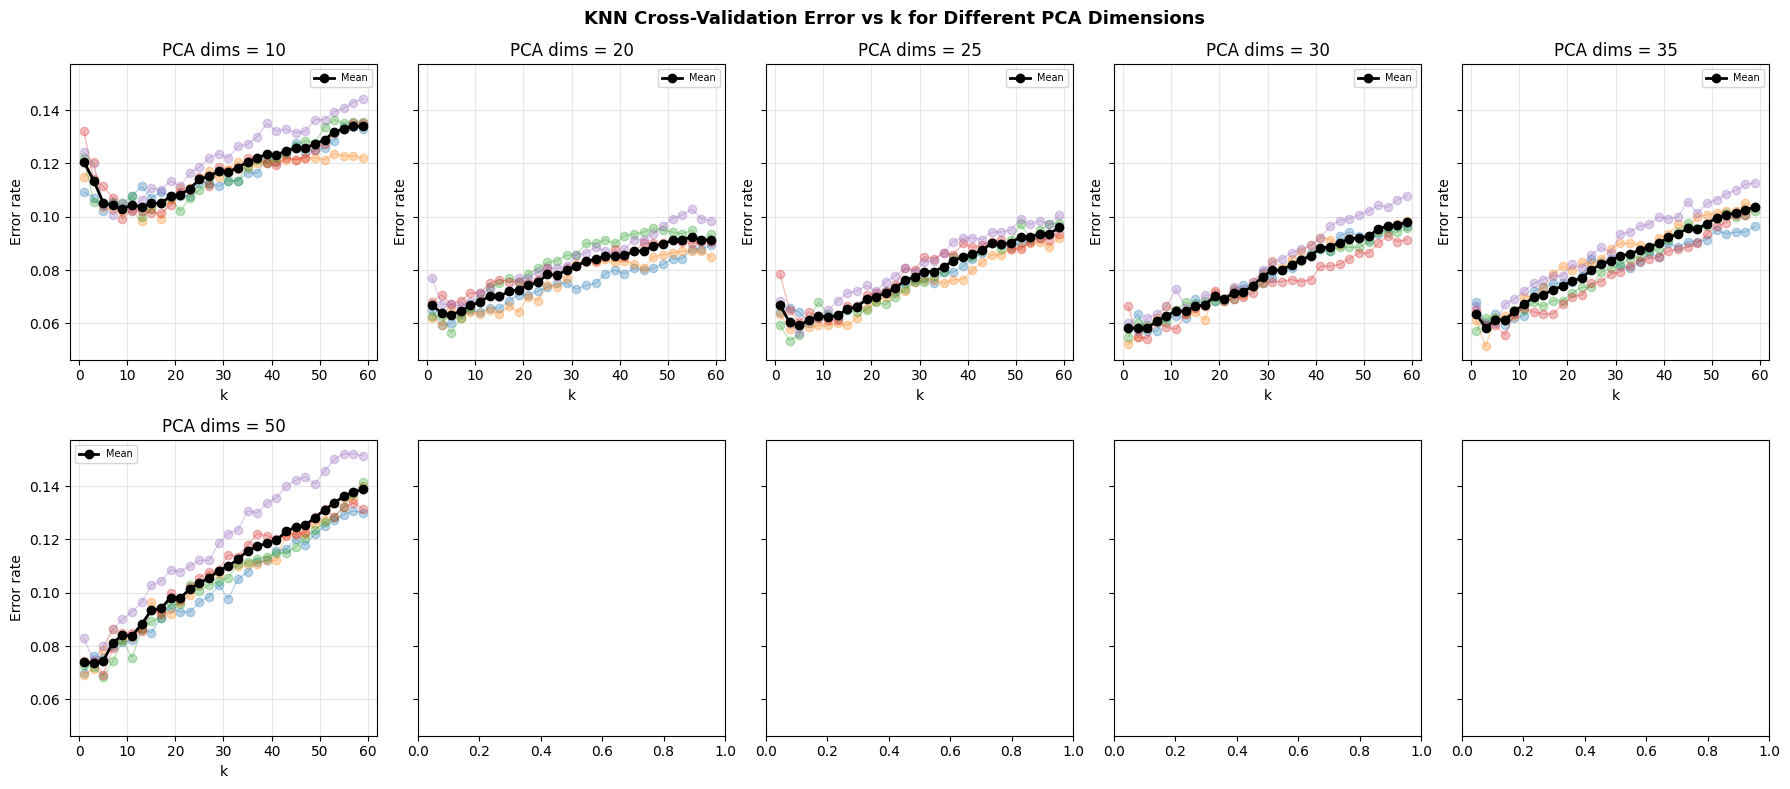

In [ ]:
dims   = [10, 20, 25, 30, 35, 50]
k_vals = [2*x+1 for x in range(30)]

# Outer dict: dim → k → list of fold errors
all_errors = {f"{d}": {f"{n}": [] for n in k_vals} for d in dims}

for d in dims:
    print(f"\n--- PCA dimensions: {d} ---")

    # Fit PCA with correct n_components for this iteration
    pca = PCA(n_components=d, svd_solver='full', whiten=True)
    pca_train = pca.fit_transform(x_train)

    for n in k_vals:
        print(f"  k={n}")

        for train_idx, val_idx in five_fold_cv.split(pca_train, np.ravel(y_train)):
            # Slice the dimension-specific PCA arrays
            pca_train_fold = pca_train[train_idx]
            y_train_fold   = np.ravel(y_train)[train_idx]
            pca_val_fold   = pca_train[val_idx]
            y_val_fold     = np.ravel(y_train)[val_idx]

            # Fit and find CV Error
            neigh = KNeighborsClassifier(n_neighbors=n, metric="euclidean")
            neigh.fit(pca_train_fold, y_train_fold)
            error = np.mean(neigh.predict(pca_val_fold) != y_val_fold)
            all_errors[f"{d}"][f"{n}"].append(error)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for i, d in enumerate(dims):
    ax = axes[i]
    
    # Individual fold errors
    n_folds = len(all_errors[f"{d}"][f"{k_vals[0]}"])
    for fold in range(n_folds):
        fold_errors = [all_errors[f"{d}"][f"{n}"][fold] for n in k_vals]
        ax.plot(k_vals, fold_errors, 'o-', alpha=0.3, lw=1)

    # Mean CV error
    mean_errors = [np.mean(all_errors[f"{d}"][f"{n}"]) for n in k_vals]
    ax.plot(k_vals, mean_errors, 'o-', color='black', lw=2, label='Mean')


    ax.set_title(f"PCA dims = {d}")
    ax.set_xlabel("k")
    ax.set_ylabel("Error rate")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle("KNN Cross-Validation Error vs k for Different PCA Dimensions",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

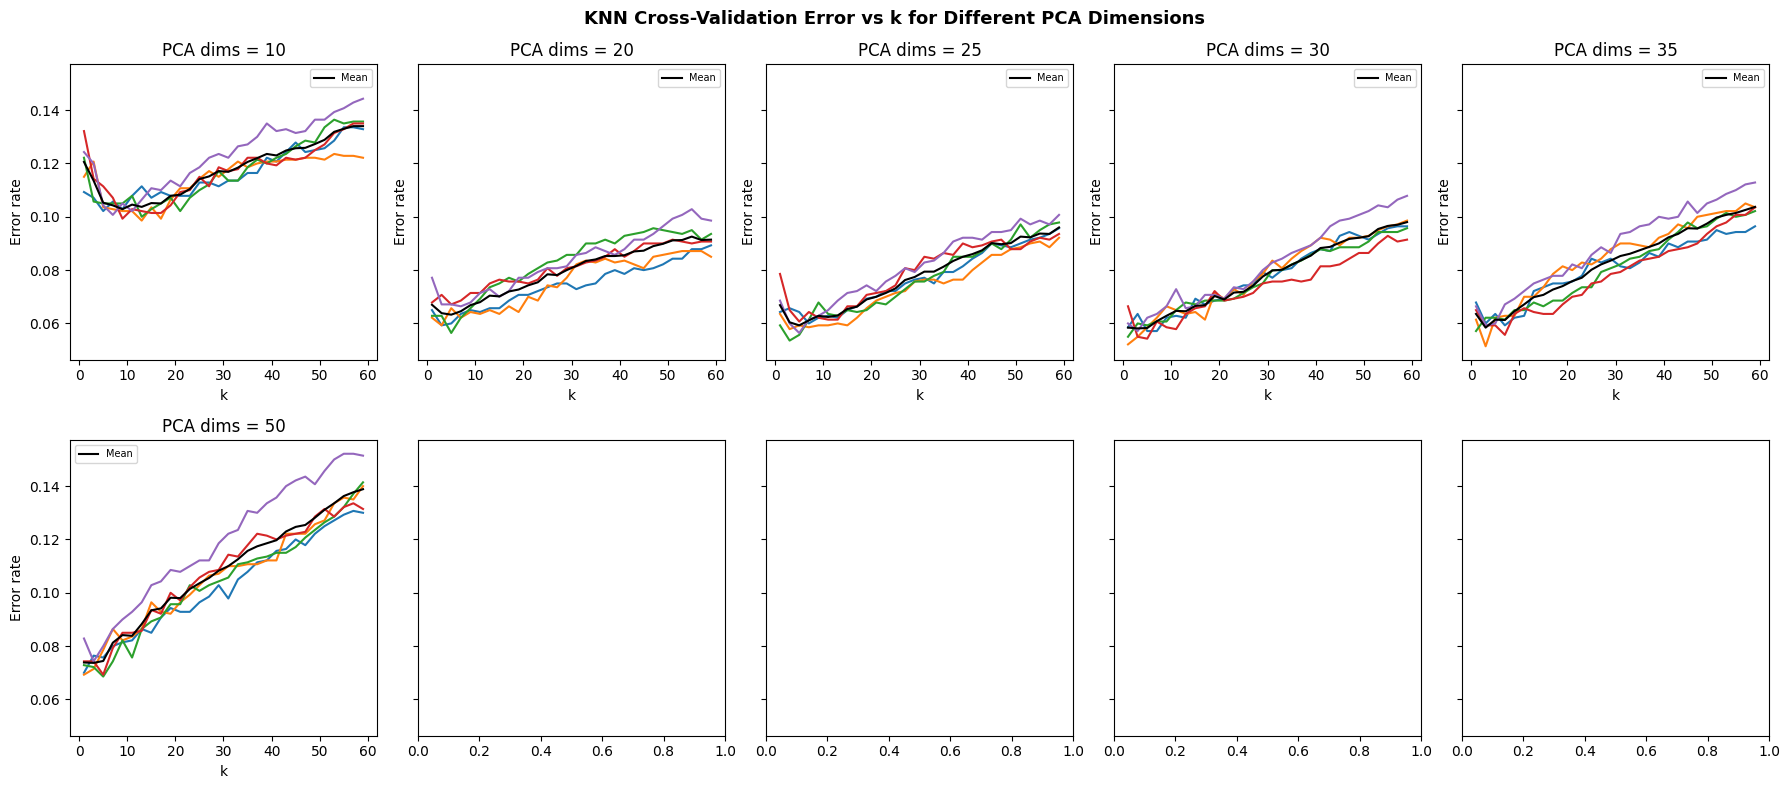

In [25]:
# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for i, d in enumerate(dims):
    ax = axes[i]
    
    # Individual fold lines
    n_folds = len(all_errors[f"{d}"][f"{k_vals[0]}"])
    for fold in range(n_folds):
        fold_errors = [all_errors[f"{d}"][f"{n}"][fold] for n in k_vals]
        ax.plot(k_vals, fold_errors)

    # Mean line
    mean_errors = [np.mean(all_errors[f"{d}"][f"{n}"]) for n in k_vals]
    ax.plot(k_vals, mean_errors,  color='black', label='Mean')

    ax.set_title(f"PCA dims = {d}")
    ax.set_xlabel("k")
    ax.set_ylabel("Error rate")
    ax.legend(fontsize=7)

plt.suptitle("KNN Cross-Validation Error vs k for Different PCA Dimensions",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

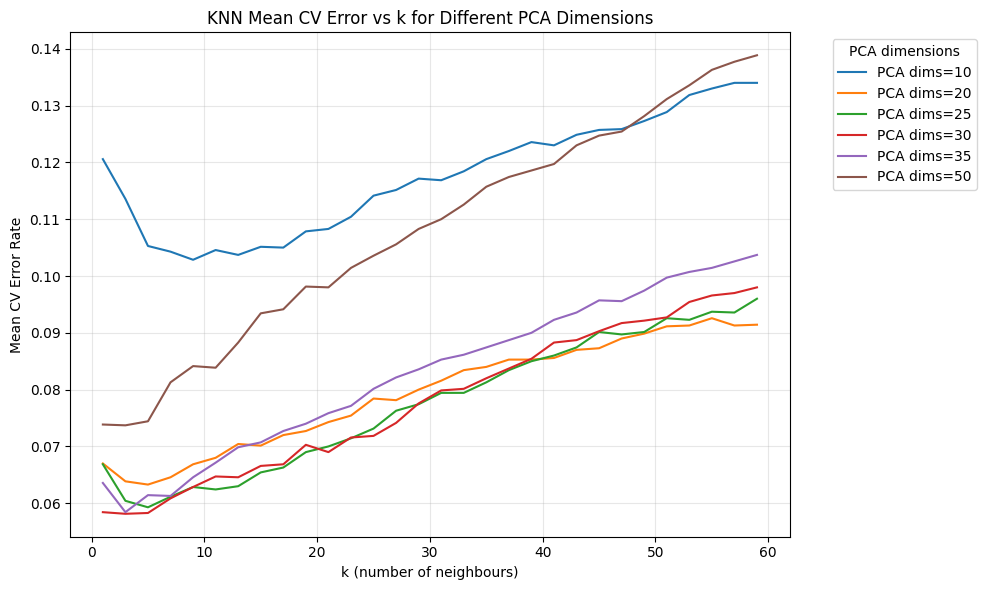

In [27]:
plt.figure(figsize=(10, 6))

for d in dims:
    mean_errors = [np.mean(all_errors[f"{d}"][f"{n}"]) for n in k_vals]
    plt.plot(k_vals, mean_errors, label=f"PCA dims={d}")

plt.xlabel("k (number of neighbours)")
plt.ylabel("Mean CV Error Rate")
plt.title("KNN Mean CV Error vs k for Different PCA Dimensions")
plt.legend(title="PCA dimensions", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()